# Laboratorio 01: Implementación de Clustering (K-Means y Jerárquico)

**Curso:** Inteligencia Artificial  
**Fecha:** 10 Febrero 2026

En este laboratorio implementaremos desde cero el algoritmo K-Means y lo compararemos con soluciones de librería (`scikit-learn`). También exploraremos el Clustering Jerárquico y aplicaremos estos métodos a diversos datasets (Iris, Pingüinos, Vinos, Países) y problemas (cuantización de color).

### Librerías utilizadas

En este laboratorio se utilizarán las siguientes librerías:

- **NumPy**: para manejo de arreglos numéricos y operaciones matemáticas básicas.
- **Matplotlib**: para visualización de resultados (se usará en incisos posteriores).
- **Pandas**: para manejo de conjuntos de datos tabulares (se usará en la evaluación del algoritmo).

> **Nota:**  
> En el inciso 1, el algoritmo de *k-means* se implementa **desde cero**, sin utilizar librerías especializadas de clustering como `scikit-learn`.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


### 1.
 Implementación de K-means

Programar desde cero (sin usar librerías de datos ni funciones especializadas), un método de agrupamiento k-means, para vectores en $\mathbb{R}^{d}$.

Como **input** se deberá dar a la función:
* La matriz de datos, una matriz numérica de $n \times d$.
* El número de grupos o clústers a construir.

Como **output**, su algoritmo debe producir:
* Un vector con las clases o labels de cada dato (vector de tamaño $n$).
* Un vector con los centroides de cada grupo (matriz de $k \times d$ donde cada fila de esta matriz es un centroide).

In [4]:
def kmeans_manual(X, k, max_iters=100, tol=1e-4):
    """
    Implementación de K-Means desde cero para vectores en R^d.
    
    Parámetros:
    - X: Matriz de datos (n x d). 'n' muestras, 'd' características.
    - k: Número de grupos (clústers).
    - max_iters: Máximo de iteraciones si no converge antes.
    
    Retorna:
    - labels: Vector (n) con la clase asignada a cada dato.
    - centroids: Matriz (k x d) con los centros de cada grupo.
    """
    
   
    X = np.array(X)
    n_samples, n_features = X.shape
    

    random_indices = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_indices]
    
    labels = np.zeros(n_samples)
    

    for i in range(max_iters):

        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        

        new_labels = np.argmin(distances, axis=1)
        

        new_centroids = np.zeros((k, n_features))
        for cluster_idx in range(k):
  
            points_in_cluster = X[new_labels == cluster_idx]
            
            if len(points_in_cluster) > 0:
      
                new_centroids[cluster_idx] = points_in_cluster.mean(axis=0)
            else:
              
                new_centroids[cluster_idx] = centroids[cluster_idx]
        


        if np.allclose(centroids, new_centroids, atol=tol):
            break
            
        centroids = new_centroids
        labels = new_labels

    return labels, centroids

### 2.
 Evaluar el funcionamiento de su algoritmo con los siguientes conjuntos de datos:

a) El conjunto de datos Iris:  
from sklearn.datasets import load_iris  
import pandas as pd  

iris = load_iris()  
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)  
df['target'] = iris.target  

b) El conjunto de datos penguins de la librería  
import seaborn as sns  
penguins = sns.load_dataset("penguins")

c) El conjunto de datos winequality-red, dentro del conjunto de datos wines:  
https://archive.ics.uci.edu/dataset/186/wine+quality  

En cada caso, elegir un número apropiado de clústers para el agrupamiento.  
Contrastar los resultados de su algoritmo de k-means contra los de la librería scikit-learn,  
y discutir las semejanzas o diferencias.


### a) Conjunto de datos Iris

El conjunto de datos Iris contiene 150 observaciones con 4 características.
Dado que existen tres clases naturales, se elige k = 3.


In [5]:
# Cargar Iris
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)

X_iris = df_iris.values

# K-means manual
labels_iris_manual, centroids_iris_manual = kmeans_manual(X_iris, k=3)

# K-means scikit-learn
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_iris_sklearn = kmeans_iris.fit_predict(X_iris)


### b) Conjunto de datos Penguins

El conjunto de datos Penguins contiene información morfológica de distintas especies.
Se eliminan valores faltantes y se consideran únicamente variables numéricas.
Dado que existen tres especies, se elige k = 3.


In [7]:
# Cargar dataset Penguins
penguins = sns.load_dataset("penguins")

# Seleccionar variables numéricas y eliminar NaNs
penguins_numeric = penguins.select_dtypes(include="number").dropna()
X_penguins = penguins_numeric.values

# K-means manual
labels_penguins_manual, centroids_penguins_manual = kmeans_manual(X_penguins, k=3)

# K-means scikit-learn
kmeans_penguins = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_penguins_sklearn = kmeans_penguins.fit_predict(X_penguins)


### c) Conjunto de datos Wine Quality (winequality-red)

Este conjunto de datos contiene características fisicoquímicas del vino tinto.
Se elige k = 6, considerando los distintos niveles de calidad.


In [8]:
# Cargar dataset Wine Quality Red
wine = pd.read_csv("winequality-red.csv", sep=";")
X_wine = wine.values

# K-means manual
labels_wine_manual, centroids_wine_manual = kmeans_manual(X_wine, k=6)

# K-means scikit-learn
kmeans_wine = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_wine_sklearn = kmeans_wine.fit_predict(X_wine)


En el conjunto de datos Iris se conoce que existen tres clases naturales,
correspondientes a las tres especies de flores presentes en el dataset.
Por este motivo se elige k = 3, con el objetivo de evaluar si el algoritmo
k-means es capaz de recuperar dicha estructura sin utilizar las etiquetas.


### 3. 
Hacer un agrupamiento jerárquico con los datos de los países countries_binary.xlsx.

Visualizar los resultados o dendrogramas de diferentes métodos de agrupamiento,
variando los siguientes:

- el método de agrupamiento (simple, completo, promedio, Ward)
- la métrica utilizada (euclideana, Hamming).


Dataset cargado: 14 países con 111 características.


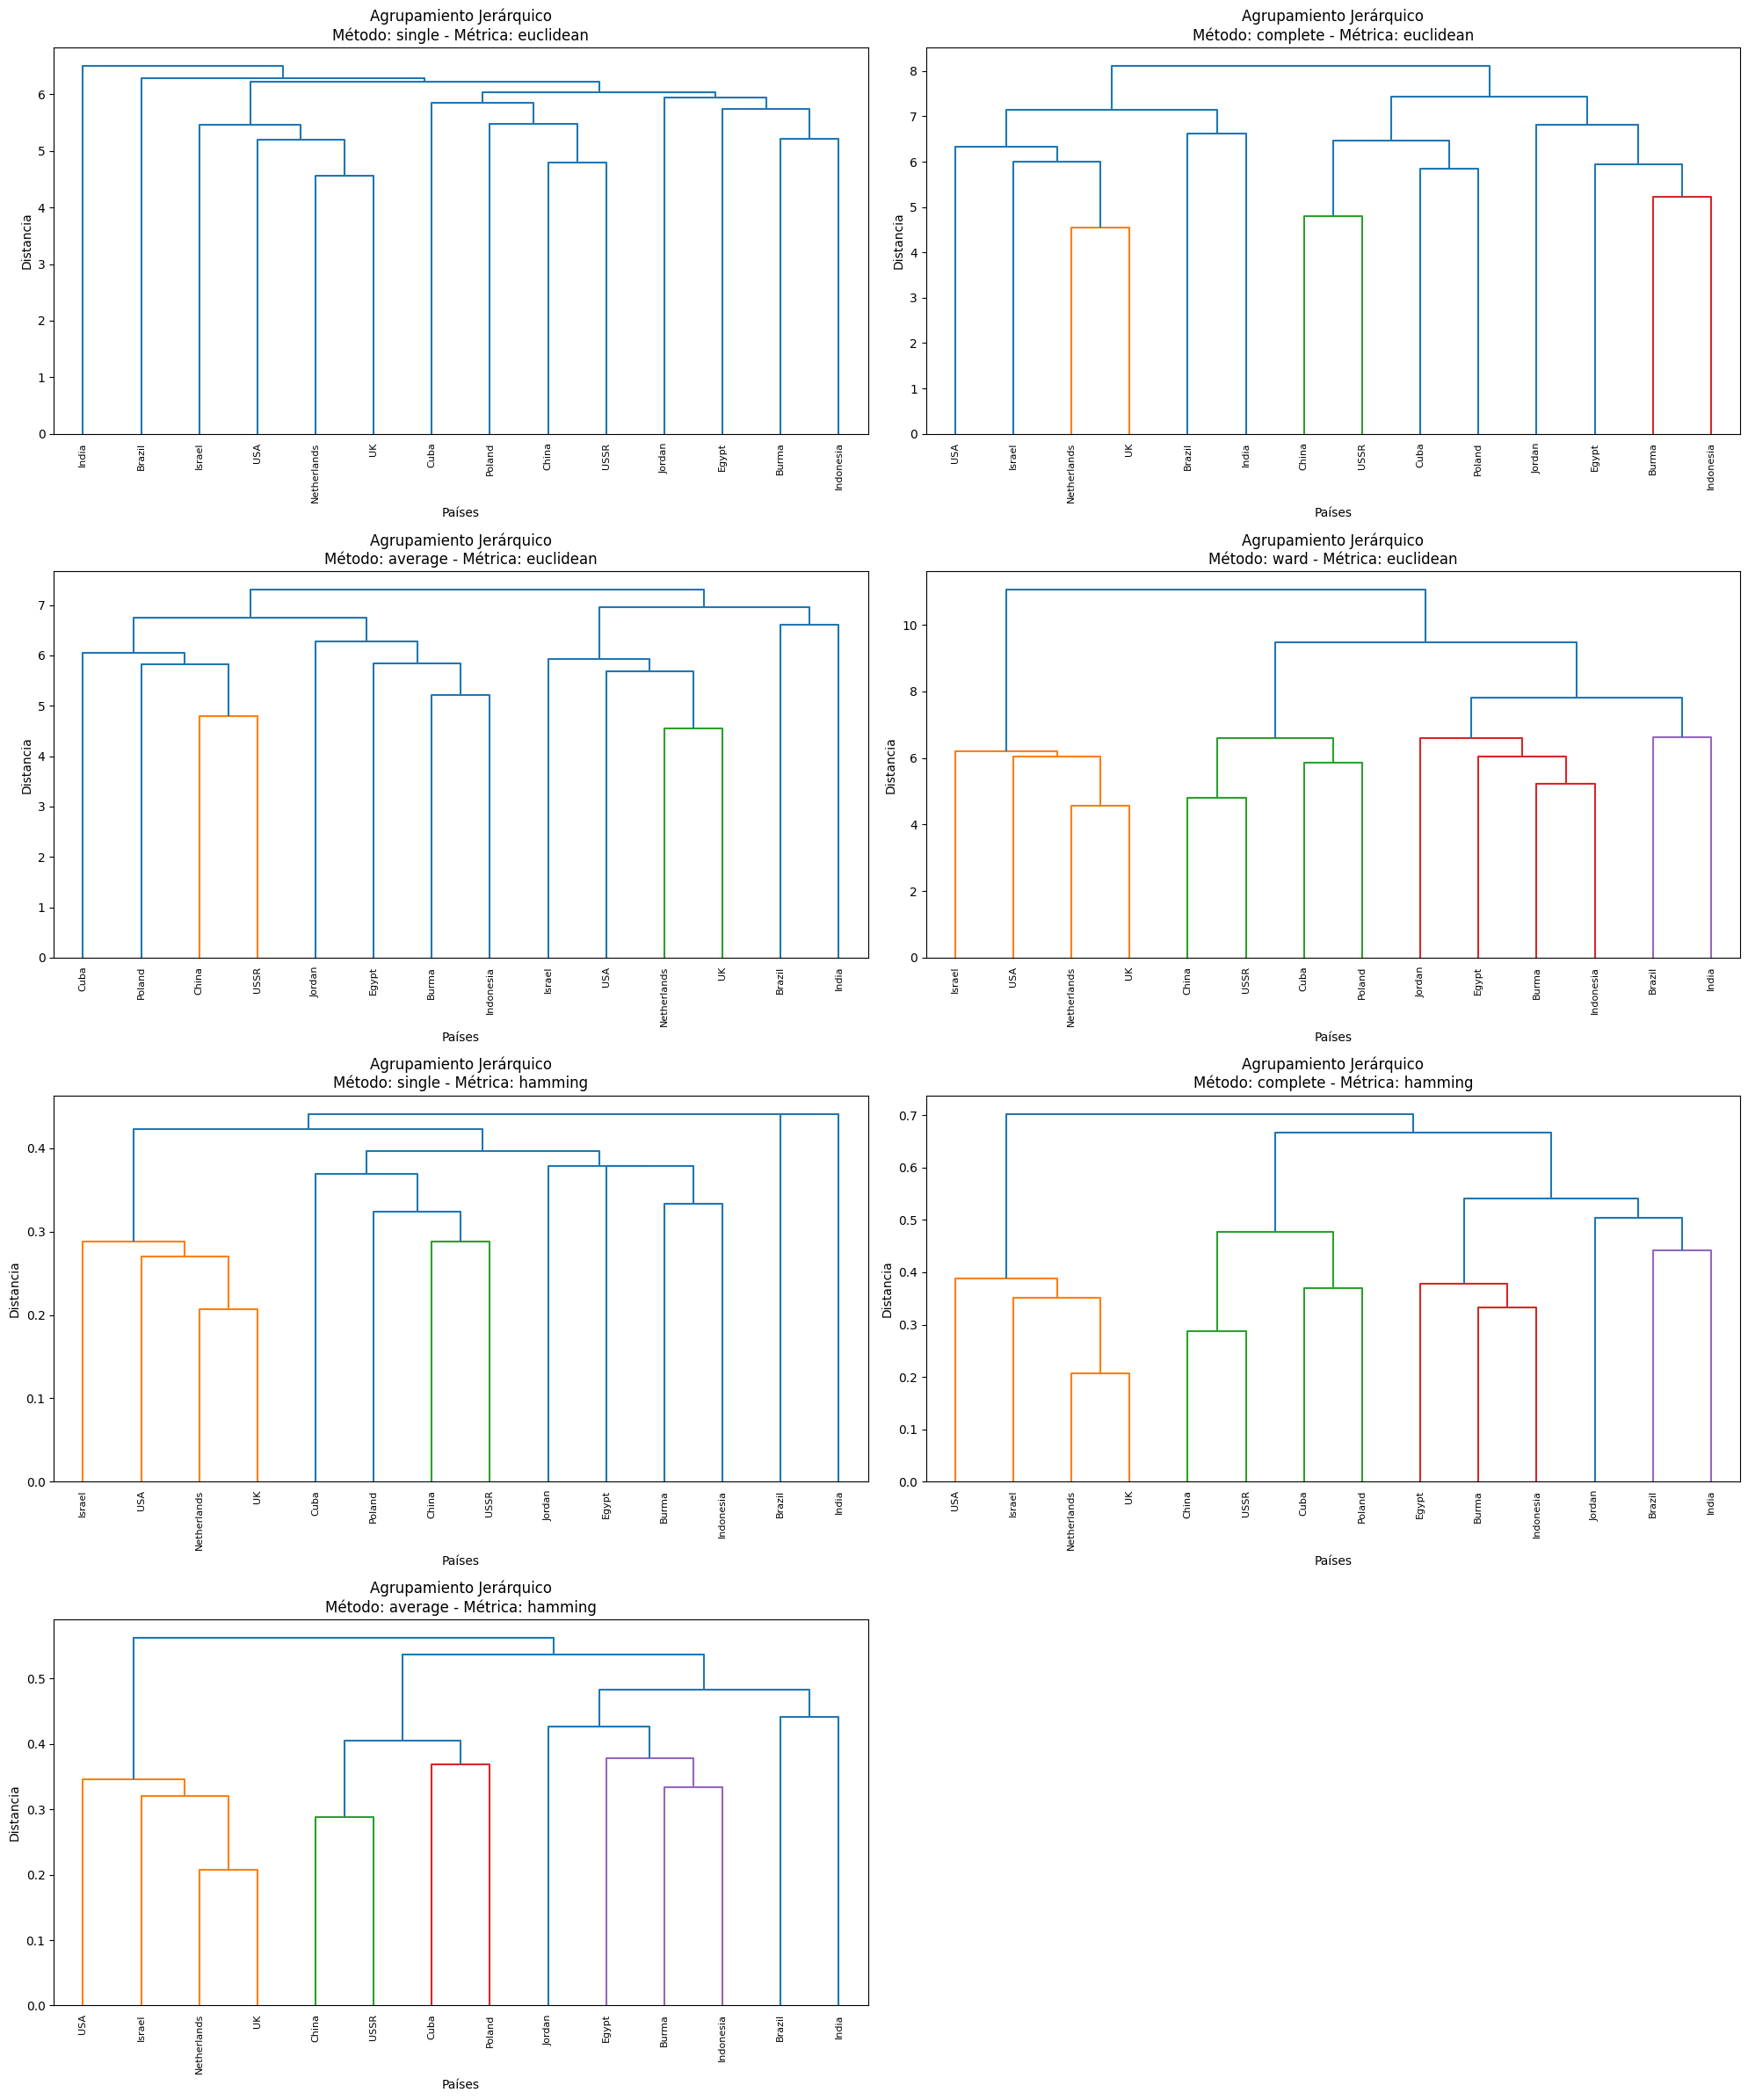

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Cargar el dataset
try:
    file_path = "countries_binary.xlsx"
    df_countries = pd.read_excel(file_path)
    
    # Asumimos que la primera columna son los nombres de los países
    # y el resto son las características binarias
    country_names = df_countries.iloc[:, 0].values
    X_countries = df_countries.iloc[:, 1:].values
    
    print(f"Dataset cargado: {X_countries.shape[0]} países con {X_countries.shape[1]} características.")

except FileNotFoundError:
    print(f"Error: El archivo {file_path} no se encuentra.")
    # Datos dummy por si falla la carga para demostrar el código
    country_names = [f"País {i}" for i in range(10)]
    X_countries = np.random.randint(0, 2, (10, 5))

# 2. Configuración de métodos y métricas
# Nota: 'ward' solo funciona correctamente con distancia euclideana en scipy
configs = [
    ('single', 'euclidean'),
    ('complete', 'euclidean'),
    ('average', 'euclidean'),
    ('ward', 'euclidean'),
    ('single', 'hamming'),
    ('complete', 'hamming'),
    ('average', 'hamming')
]

# 3. Generar Dendrogramas
plt.figure(figsize=(20, 24))

for i, (method, metric) in enumerate(configs, 1):
    plt.subplot(4, 2, i)
    
    # Calcular la matriz de enlace (linkage matrix)
    try:
        Z = linkage(X_countries, method=method, metric=metric)
        
        # Graficar dendrograma
        dendrogram(
            Z,
            labels=country_names,
            leaf_rotation=90,
            leaf_font_size=8
        )
        
        plt.title(f"Agrupamiento Jerárquico\nMétodo: {method} - Métrica: {metric}")
        plt.xlabel("Países")
        plt.ylabel("Distancia")
        
    except Exception as e:
        plt.text(0.5, 0.5, f"Error en config: {method}/{metric}\n{e}", 
                 ha='center', va='center')
        plt.title(f"Método: {method} - Métrica: {metric}")

plt.tight_layout()
plt.show()

### 4. 
Realizar un análisis de agrupamiento k-means, nuevamente para los datos de los países,
que están disponibles en el archivo countries_binary.xlsx.

Contrastar con el ejercicio anterior. ¿Son iguales las agrupaciones? ¿Por qué?
Justificar.


In [2]:
from sklearn.cluster import KMeans

# 1. Aplicar K-Means con un k comparable 
# (Observando los dendrogramas previos, podemos elegir un corte o un k arbitrario razonable)
k_countries = 6
kmeans = KMeans(n_clusters=k_countries, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_countries)

# 2. Mostrar los grupos formados
print(f"Resultados de K-Means (k={k_countries}):")
df_results = pd.DataFrame({'País': country_names, 'Cluster': labels_kmeans})

for i in range(k_countries):
    paises_cluster = df_results[df_results['Cluster'] == i]['País'].tolist()
    print(f"\nCluster {i}:")
    print(", ".join(paises_cluster))

# 3. Contraste y Justificación
justificacion = """
--- ANÁLISIS COMPARATIVO ---

¿Son iguales las agrupaciones?
En general, NO suelen ser idénticas. Es probable ver diferencias significativas entre los grupos de K-means y los del agrupamiento jerárquico (especialmente el basado en métrica Hamming).

¿Por qué? Justificación:

1. Naturaleza de los Datos y Métricas de Distancia:
   - K-means utiliza distancias Euclidianas y calcula 'centroides' promediando las posiciones de los puntos. 
   - El dataset es BINARIO (0s y 1s). El promedio de vectores binarios da valores decimales (ej. 0.5) que no existen en el espacio original de las características.
   - La distancia Euclideana no siempre es la mejor para datos categóricos/binarios. La distancia de Hamming (usada en una de las variantes jerárquicas) es más natural para este tipo de datos, ya que cuenta el número de desacuerdos bit a bit.

2. Forma de los Clusters:
   - K-means asume clusters esféricos (o hiperesféricos) y de tamaño similar debido a su optimización basada en varianza.
   - El agrupamiento jerárquico no asume una forma geométrica específica en los clusters; simplemente agrupa basado en proximidad directa (linkage), permitiendo formas más arbitrarias o 'alargadas' si la conectividad lo dicta.

3. Estructura del Algoritmo:
   - K-means es un algoritmo de partición plana (flat clustering).
   - El jerárquico construye una estructura anidada (árbol), donde las decisiones tomadas en pasos tempranos (agrupaciones iniciales) son irrevocables.
"""

print(justificacion)

Resultados de K-Means (k=6):

Cluster 0:
Israel, Netherlands, UK, USA

Cluster 1:
Burma, Egypt, Indonesia

Cluster 2:
Brazil, Cuba

Cluster 3:
China, Poland, USSR

Cluster 4:
Jordan

Cluster 5:
India

--- ANÁLISIS COMPARATIVO ---

¿Son iguales las agrupaciones?
En general, NO suelen ser idénticas. Es probable ver diferencias significativas entre los grupos de K-means y los del agrupamiento jerárquico (especialmente el basado en métrica Hamming).

¿Por qué? Justificación:

1. Naturaleza de los Datos y Métricas de Distancia:
   - K-means utiliza distancias Euclidianas y calcula 'centroides' promediando las posiciones de los puntos. 
   - El dataset es BINARIO (0s y 1s). El promedio de vectores binarios da valores decimales (ej. 0.5) que no existen en el espacio original de las características.
   - La distancia Euclideana no siempre es la mejor para datos categóricos/binarios. La distancia de Hamming (usada en una de las variantes jerárquicas) es más natural para este tipo de datos, ya q

### 5.
 Generar un conjunto de datos sintéticos, de tamaño 200, con make_moons o círculos concéntricos de Scikit-learn. (Aquí la idea es realizar dos clúster,
con 100 observaciones cada una).

Una vez tenga fijado el conjunto de datos, comparar los algoritmos de clustering.

(a) Explicar lo siguiente: ¿Por qué k-means falla con formas de “luna” o anillos
concéntricos?

(b) Comparar k-means vs. agrupamiento jerárquico. ¿Cuál produce mejores resultados?
¿Por qué? ¿Cuál es el método y la métrica que funcionan mejor en el agrupamiento
jerárquico?


### 6.
 Realizar un algoritmo de cuantización de colores para imágenes RGB,
usando como base un algoritmo de agrupamiento.

Ilustrar los resultados obtenidos con 3 imágenes de su elección. En cada una mostrar:

- El mapa de clases resultado del agrupamiento.
- La imagen cuantizada resultante.
